# **Miniproyecto Lending Club Loan Data**

## **Analisis Exploratorio**

Por: Luis Esteban Mariño,Alejandro Carvajal y Juan Esteban Garcia

### **Contexto**

Lending Club es una plataforma financiera estadounidense que realiza préstamos personales bajo el modelo (P2P), donde inversionistas financian directamente las solicitudes de crédito de los clientes. Esta base de datos contiene los préstamos aprobados por la plataforma entre 2007 y 2020, donde se tiene cada uno de los detalles importantes de sus clientes y su comportamiento crediticio .

### **Planteamiento del problema**

El crecimiento de las plataformas de préstamos digitales  durante los ultomso años ha obligado a estaos servicios financieros a evaluar los riesgos crediticios de manera precisa y escalable. Debido a esto, Lending Club enfrenta el desafío de identificar qué préstamos tienen alta probabilidad de incumplimiento  antes de ser otorgados. Una mala evaluación del riesgo puede generar  pérdidas significativas tanto para la plataforma como para los usuarios. En este contexto, surge la necesidad de construir un modelo predictivo, a partir de las características del solicitante y del préstamo, y se pueda anticipar si se va a pagar el credito o no.

### **Objetivos y justificación**

#### **Objetivo General**

Construir y comparar modelos de clasificación supervisada para predecir el incumplimiento en el pago de préstamos que son emitidos por Lending Club, evaluando el desempeño de scikit-learn frente a PySpark e incorporando el metodo LIME.


#### **Objetivos específicos**

- Realizar un análisis exploratorio del dataset para comprender la distribución de las variables y la variable objetivo
- Preprocesar los datos aplicando codificación, escalado y división estratificada
- Entrenar un modelo Random Forest con optimización de hiperparámetros en scikit-learn y PySpark
- Comparar métricas de desempeño 
- Interpretar predicciones individuales mediante LIME

#### **Justificación**
La predicción del riesgo crediticio es uno de los problemas más relevantes en la industria financiera. Es importante contar con modelos precisos que ayuda a tener mayor informacion en las tomas de decisiones y reducir posibles pérdidas. Adicionalmente, la comparación entre scikit-learn y PySpark aporta valor práctico al evaluar qué modelo es más adecuado según el volumen de datos y sus caracteristicas.

### **Descripcion de variables**



In [4]:
import pandas as pd

variables = [
    ("id", "Identificador único del préstamo en la plataforma Lending Club", "Numérica"),
    ("member_id", "Identificador único del miembro solicitante del préstamo", "Numérica"),
    ("loan_amnt", "Monto total solicitado por el prestatario en dólares", "Numérica"),
    ("funded_amnt", "Monto total comprometido para el préstamo hasta la fecha", "Numérica"),
    ("funded_amnt_inv", "Monto total comprometido por los inversionistas para ese préstamo", "Numérica"),
    ("term", "Plazo del préstamo en meses (36 o 60 meses)", "Categórica"),
    ("int_rate", "Tasa de interés anual asignada al préstamo expresada en porcentaje", "Numérica"),
    ("installment", "Cuota mensual que debe pagar el prestatario si el préstamo es financiado", "Numérica"),
    ("grade", "Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)", "Categórica"),
    ("sub_grade", "Subclasificación más detallada dentro de cada grado de riesgo", "Categórica"),
    ("emp_title", "Cargo o título del empleo del solicitante", "Categórica"),
    ("emp_length", "Años de antigüedad laboral del solicitante (0 a 10 años)", "Categórica"),
    ("home_ownership", "Tipo de tenencia de vivienda del solicitante (propia, hipotecada, arrendada, entre otras)", "Categórica"),
    ("annual_inc", "Ingreso anual reportado por el solicitante en dólares", "Numérica"),
    ("verification_status", "Indica si el ingreso del solicitante fue verificado por Lending Club", "Categórica"),
    ("issue_d", "Fecha en que el préstamo fue emitido", "Fecha"),
    ("loan_status", "Estado actual del préstamo. Es la variable objetivo del modelo", "Categórica"),
    ("pymnt_plan", "Indica si el prestatario tiene un plan de pago activo (s/n)", "Categórica"),
    ("url", "URL del préstamo en la plataforma Lending Club", "Texto"),
    ("desc", "Descripción textual del préstamo proporcionada por el solicitante", "Texto"),
    ("purpose", "Propósito declarado del préstamo (consolidación de deudas, mejoras del hogar, educación, médico, etc.)", "Categórica"),
    ("title", "Título del préstamo proporcionado por el solicitante", "Texto"),
    ("zip_code", "Primeros tres dígitos del código postal del solicitante", "Categórica"),
    ("addr_state", "Estado de residencia del solicitante en Estados Unidos", "Categórica"),
    ("dti", "Relación deuda-ingreso del solicitante", "Numérica"),
    ("delinq_2yrs", "Número de veces que el solicitante tuvo mora de más de 30 días en los últimos 2 años", "Numérica"),
    ("earliest_cr_line", "Fecha de apertura de la primera línea de crédito del solicitante", "Fecha"),
    ("fico_range_low", "Límite inferior del rango de puntaje crediticio FICO al momento de la solicitud", "Numérica"),
    ("fico_range_high", "Límite superior del rango de puntaje crediticio FICO al momento de la solicitud", "Numérica"),
    ("inq_last_6mths", "Número de consultas al buró de crédito realizadas en los últimos 6 meses", "Numérica"),
    ("mths_since_last_delinq", "Meses transcurridos desde la última mora del solicitante", "Numérica"),
    ("mths_since_last_record", "Meses transcurridos desde el último registro público negativo del solicitante", "Numérica"),
    ("open_acc", "Número de líneas de crédito activas del solicitante", "Numérica"),
    ("pub_rec", "Número de registros públicos negativos del solicitante (quiebras, embargos, etc.)", "Numérica"),
    ("revol_bal", "Saldo total de crédito revolvente del solicitante en dólares", "Numérica"),
    ("revol_util", "Porcentaje de utilización del crédito revolvente disponible", "Numérica"),
    ("total_acc", "Número total de líneas de crédito en el historial del solicitante", "Numérica"),
    ("initial_list_status", "Estado inicial de publicación del préstamo en la plataforma (w: whole, f: fractional)", "Categórica"),
    ("out_prncp", "Saldo de capital pendiente de pago del préstamo", "Numérica"),
    ("out_prncp_inv", "Saldo de capital pendiente correspondiente a la porción financiada por inversionistas", "Numérica"),
    ("total_pymnt", "Total de pagos recibidos hasta la fecha, incluyendo capital e intereses", "Numérica"),
    ("total_pymnt_inv", "Total de pagos recibidos por los inversionistas hasta la fecha", "Numérica"),
    ("total_rec_prncp", "Capital total recuperado hasta la fecha", "Numérica"),
    ("total_rec_int", "Intereses totales recuperados hasta la fecha", "Numérica"),
    ("total_rec_late_fee", "Cargos por mora recuperados hasta la fecha", "Numérica"),
    ("recoveries", "Monto recuperado tras declararse el préstamo en default", "Numérica"),
    ("collection_recovery_fee", "Comisión cobrada por la gestión de cobro del préstamo en default", "Numérica"),
    ("last_pymnt_d", "Fecha del último pago recibido", "Fecha"),
    ("last_pymnt_amnt", "Monto del último pago recibido", "Numérica"),
    ("next_pymnt_d", "Fecha programada del próximo pago", "Fecha"),
    ("last_credit_pull_d", "Fecha de la última consulta al buró de crédito realizada por Lending Club", "Fecha"),
    ("last_fico_range_high", "Límite superior del puntaje FICO más reciente del solicitante", "Numérica"),
    ("last_fico_range_low", "Límite inferior del puntaje FICO más reciente del solicitante", "Numérica"),
    ("collections_12_mths_ex_med", "Número de cobros judiciales en los últimos 12 meses, excluyendo deudas médicas", "Numérica"),
    ("mths_since_last_major_derog", "Meses transcurridos desde la última calificación crediticia negativa grave", "Numérica"),
    ("policy_code", "Código de política de préstamo disponible públicamente (1 = disponible, 2 = no disponible)", "Categórica"),
    ("application_type", "Indica si la solicitud es individual o conjunta", "Categórica"),
    ("annual_inc_joint", "Ingreso anual combinado de ambos solicitantes en caso de solicitud conjunta", "Numérica"),
    ("dti_joint", "Relación deuda-ingreso combinada en solicitudes conjuntas", "Numérica"),
    ("verification_status_joint", "Estado de verificación del ingreso en solicitudes conjuntas", "Categórica"),
    ("acc_now_delinq", "Número de cuentas en mora actualmente", "Numérica"),
    ("tot_coll_amt", "Monto total en cobro judicial en el historial del solicitante", "Numérica"),
    ("tot_cur_bal", "Saldo total actual de todas las cuentas del solicitante", "Numérica"),
    ("open_acc_6m", "Número de cuentas abiertas en los últimos 6 meses", "Numérica"),
    ("open_act_il", "Número de cuentas de crédito a plazos activas actualmente", "Numérica"),
    ("open_il_12m", "Número de cuentas de crédito a plazos abiertas en los últimos 12 meses", "Numérica"),
    ("open_il_24m", "Número de cuentas de crédito a plazos abiertas en los últimos 24 meses", "Numérica"),
    ("mths_since_rcnt_il", "Meses transcurridos desde la apertura de la cuenta de crédito a plazos más reciente", "Numérica"),
    ("total_bal_il", "Saldo total de todas las cuentas de crédito a plazos del solicitante", "Numérica"),
    ("il_util", "Porcentaje de utilización del crédito a plazos respecto al límite total", "Numérica"),
    ("open_rv_12m", "Número de cuentas de crédito revolvente abiertas en los últimos 12 meses", "Numérica"),
    ("open_rv_24m", "Número de cuentas de crédito revolvente abiertas en los últimos 24 meses", "Numérica"),
    ("max_bal_bc", "Saldo máximo actual entre todas las tarjetas de crédito del solicitante", "Numérica"),
    ("all_util", "Porcentaje de utilización de crédito sobre todas las líneas del solicitante", "Numérica"),
    ("total_rev_hi_lim", "Límite de crédito revolvente total del solicitante", "Numérica"),
    ("inq_fi", "Número de consultas al buró realizadas por entidades de financiamiento personal", "Numérica"),
    ("total_cu_tl", "Número total de cuentas de uniones de crédito del solicitante", "Numérica"),
    ("inq_last_12m", "Número de consultas al buró de crédito en los últimos 12 meses", "Numérica"),
    ("acc_open_past_24mths", "Número de cuentas abiertas en los últimos 24 meses", "Numérica"),
    ("avg_cur_bal", "Saldo promedio actual entre todas las cuentas del solicitante", "Numérica"),
    ("bc_open_to_buy", "Crédito disponible total en tarjetas de crédito activas", "Numérica"),
    ("bc_util", "Porcentaje de utilización del crédito en tarjetas de crédito", "Numérica"),
    ("chargeoff_within_12_mths", "Número de castigos contables registrados en los últimos 12 meses", "Numérica"),
    ("delinq_amnt", "Monto total en mora del solicitante actualmente", "Numérica"),
    ("mo_sin_old_il_acct", "Meses desde la apertura de la cuenta de crédito a plazos más antigua", "Numérica"),
    ("mo_sin_old_rev_tl_op", "Meses desde la apertura de la cuenta de crédito revolvente más antigua", "Numérica"),
    ("mo_sin_rcnt_rev_tl_op", "Meses desde la apertura de la cuenta de crédito revolvente más reciente", "Numérica"),
    ("mo_sin_rcnt_tl", "Meses desde la apertura de la cuenta de crédito más reciente de cualquier tipo", "Numérica"),
    ("mort_acc", "Número de cuentas hipotecarias en el historial del solicitante", "Numérica"),
    ("mths_since_recent_bc", "Meses desde la apertura de la tarjeta de crédito más reciente", "Numérica"),
    ("mths_since_recent_bc_dlq", "Meses desde la última mora en tarjeta de crédito", "Numérica"),
    ("mths_since_recent_inq", "Meses desde la consulta al buró de crédito más reciente", "Numérica"),
    ("mths_since_recent_revol_delinq", "Meses desde la última mora en una cuenta de crédito revolvente", "Numérica"),
    ("num_accts_ever_120_pd", "Número de cuentas que alguna vez tuvieron 120 o más días de mora", "Numérica"),
    ("num_actv_bc_tl", "Número de tarjetas de crédito activas actualmente", "Numérica"),
    ("num_actv_rev_tl", "Número de cuentas de crédito revolvente activas actualmente", "Numérica"),
    ("num_bc_sats", "Número de tarjetas de crédito en buen estado (al día)", "Numérica"),
    ("num_bc_tl", "Número total de tarjetas de crédito en el historial del solicitante", "Numérica"),
    ("num_il_tl", "Número total de cuentas de crédito a plazos en el historial del solicitante", "Numérica"),
    ("num_op_rev_tl", "Número de cuentas de crédito revolvente abiertas actualmente", "Numérica"),
    ("num_rev_accts", "Número total de cuentas de crédito revolvente en el historial", "Numérica"),
    ("num_rev_tl_bal_gt_0", "Número de cuentas de crédito revolvente con saldo mayor a cero", "Numérica"),
    ("num_sats", "Número total de cuentas en buen estado del solicitante", "Numérica"),
    ("num_tl_120dpd_2m", "Número de cuentas con 120 o más días de mora en los últimos 2 meses", "Numérica"),
    ("num_tl_30dpd", "Número de cuentas con 30 o más días de mora actualmente", "Numérica"),
    ("num_tl_90g_dpd_24m", "Número de cuentas con 90 o más días de mora en los últimos 24 meses", "Numérica"),
    ("num_tl_op_past_12m", "Número de cuentas abiertas en los últimos 12 meses", "Numérica"),
    ("pct_tl_nvr_dlq", "Porcentaje de cuentas en el historial del solicitante que nunca han tenido mora", "Numérica"),
    ("percent_bc_gt_75", "Porcentaje de tarjetas de crédito con utilización superior al 75%", "Numérica"),
    ("pub_rec_bankruptcies", "Número de quiebras registradas en el historial público del solicitante", "Numérica"),
    ("tax_liens", "Número de embargos fiscales registrados en el historial del solicitante", "Numérica"),
    ("tot_hi_cred_lim", "Límite de crédito total más alto registrado en el historial del solicitante", "Numérica"),
    ("total_bal_ex_mort", "Saldo total de todas las cuentas excluyendo deudas hipotecarias", "Numérica"),
    ("total_bc_limit", "Límite de crédito total de todas las tarjetas de crédito del solicitante", "Numérica"),
    ("total_il_high_credit_limit", "Límite de crédito total más alto en cuentas de crédito a plazos", "Numérica"),
    ("revol_bal_joint", "Saldo total de crédito revolvente combinado en solicitudes conjuntas", "Numérica"),
    ("sec_app_fico_range_low", "Límite inferior del puntaje FICO del segundo solicitante en solicitudes conjuntas", "Numérica"),
    ("sec_app_fico_range_high", "Límite superior del puntaje FICO del segundo solicitante en solicitudes conjuntas", "Numérica"),
    ("sec_app_earliest_cr_line", "Fecha de apertura de la primera línea de crédito del segundo solicitante", "Fecha"),
    ("sec_app_inq_last_6mths", "Número de consultas al buró del segundo solicitante en los últimos 6 meses", "Numérica"),
    ("sec_app_mort_acc", "Número de cuentas hipotecarias del segundo solicitante", "Numérica"),
    ("sec_app_open_acc", "Número de líneas de crédito activas del segundo solicitante", "Numérica"),
    ("sec_app_revol_util", "Porcentaje de utilización del crédito revolvente del segundo solicitante", "Numérica"),
    ("sec_app_open_act_il", "Número de cuentas de crédito a plazos activas del segundo solicitante", "Numérica"),
    ("sec_app_num_rev_accts", "Número total de cuentas de crédito revolvente del segundo solicitante", "Numérica"),
    ("sec_app_chargeoff_within_12_mths", "Número de castigos contables del segundo solicitante en los últimos 12 meses", "Numérica"),
    ("sec_app_collections_12_mths_ex_med", "Número de cobros judiciales del segundo solicitante en los últimos 12 meses, excluyendo deudas médicas", "Numérica"),
    ("sec_app_mths_since_last_major_derog", "Meses desde la última calificación crediticia negativa grave del segundo solicitante", "Numérica"),
    ("hardship_flag", "Indica si el prestatario tiene activo un plan de dificultad financiera (s/n)", "Categórica"),
    ("hardship_type", "Tipo de plan de dificultad financiera aplicado al préstamo", "Categórica"),
    ("hardship_reason", "Razón declarada por el prestatario para solicitar el plan de dificultad financiera", "Categórica"),
    ("hardship_status", "Estado actual del plan de dificultad financiera", "Categórica"),
    ("deferral_term", "Número de meses de aplazamiento de pagos bajo el plan de dificultad financiera", "Numérica"),
    ("hardship_amount", "Monto mensual reducido bajo el plan de dificultad financiera", "Numérica"),
    ("hardship_start_date", "Fecha de inicio del plan de dificultad financiera", "Fecha"),
    ("hardship_end_date", "Fecha de finalización del plan de dificultad financiera", "Fecha"),
    ("payment_plan_start_date", "Fecha de inicio del plan de pagos reducidos", "Fecha"),
    ("hardship_length", "Duración en meses del plan de dificultad financiera", "Numérica"),
    ("hardship_dpd", "Días de mora acumulados durante el plan de dificultad financiera", "Numérica"),
    ("hardship_loan_status", "Estado del préstamo al momento de activarse el plan de dificultad financiera", "Categórica"),
    ("orig_projected_additional_accrued_interest", "Interés adicional proyectado que se acumulará durante el período de aplazamiento", "Numérica"),
    ("hardship_payoff_balance_amount", "Saldo pendiente del préstamo al inicio del plan de dificultad financiera", "Numérica"),
    ("hardship_last_payment_amount", "Monto del último pago realizado antes del plan de dificultad financiera", "Numérica"),
    ("disbursement_method", "Método de desembolso del préstamo (transferencia bancaria, cheque, etc.)", "Categórica"),
    ("debt_settlement_flag", "Indica si el prestatario ha ingresado a un programa de negociación de deuda (s/n)", "Categórica"),
    ("debt_settlement_flag_date", "Fecha en que se activó la bandera de negociación de deuda", "Fecha"),
    ("settlement_status", "Estado actual de la negociación de deuda del préstamo", "Categórica"),
    ("settlement_date", "Fecha en que se alcanzó el acuerdo de negociación de deuda", "Fecha"),
    ("settlement_amount", "Monto acordado en la negociación de deuda", "Numérica"),
    ("settlement_percentage", "Porcentaje del saldo original que cubre el acuerdo de negociación", "Numérica"),
    ("settlement_term", "Número de meses acordados para completar el pago de la negociación de deuda", "Numérica"),
]

df_variables = pd.DataFrame(variables, columns=["Variable", "Descripción", "Tipo"])
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df_variables

,Variable,Descripción,Tipo
0,id,Identificador único del préstamo en la plataforma Lending Club,Numérica
1,member_id,Identificador único del miembro solicitante del préstamo,Numérica
2,loan_amnt,Monto total solicitado por el prestatario en dólares,Numérica
3,funded_amnt,Monto total comprometido para el préstamo hasta la fecha,Numérica
4,funded_amnt_inv,Monto total comprometido por los inversionistas para ese préstamo,Numérica
5,term,Plazo del préstamo en meses (36 o 60 meses),Categórica
6,int_rate,Tasa de interés anual asignada al préstamo expresada en porcentaje,Numérica
7,installment,Cuota mensual que debe pagar el prestatario si el préstamo es financiado,Numérica
8,grade,"Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)",Categórica
9,sub_grade,Subclasificación más detallada dentro de cada grado de riesgo,Categórica


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\leste\OneDrive\Escritorio\Machine\miniproyecto\accepted_2007_to_2018Q4.csv")

C:\Users\leste\AppData\Local\Temp\ipykernel_17456\1382772191.py:3: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\leste\OneDrive\Escritorio\Machine\miniproyecto\accepted_2007_to_2018Q4.csv")


In [6]:
df = df.dropna(how='all')
df.shape

(2260701, 151)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


### Datos N/A

In [8]:
df_va = df.copy()

datos_faltantes = df_va.isnull().sum()
Porcentaje_de_datos_faltantes = (df_va.isnull().mean() * 100).round(2)
df_faltantes = pd.DataFrame({
    "Datos Faltantes": datos_faltantes,
    "Porcentaje de Datos Faltantes": Porcentaje_de_datos_faltantes
}).sort_values("Porcentaje de Datos Faltantes", ascending=False)
df_faltantes

,Datos Faltantes,Porcentaje de Datos Faltantes
member_id,2260701,100.00
orig_projected_additional_accrued_interest,2252050,99.62
hardship_end_date,2249784,99.52
hardship_start_date,2249784,99.52
hardship_type,2249784,99.52
hardship_reason,2249784,99.52
hardship_status,2249784,99.52
deferral_term,2249784,99.52
hardship_last_payment_amount,2249784,99.52
hardship_payoff_balance_amount,2249784,99.52


In [9]:
umbral_columnas = 8

columnas_eliminar = df_faltantes[df_faltantes["Porcentaje de Datos Faltantes"] > umbral_columnas].index.tolist()

print(f"Columnas eliminadas: {len(columnas_eliminar)}")
print(f"Columnas restantes: {df_va.shape[1] - len(columnas_eliminar)}")

df_va = df_va.drop(columns=columnas_eliminar)
print(f"Shape final: {df_va.shape}")

Columnas eliminadas: 59
Columnas restantes: 92
Shape final: (2260701, 92)


#### **N/A despues de limpieza de columnas**



In [10]:
import pandas as pd
df_faltantes2 = pd.DataFrame({
    "Datos Faltantes": df_va.isnull().sum(),
    "Porcentaje de Datos Faltantes": (df_va.isnull().mean() * 100).round(2)
}).sort_values("Porcentaje de Datos Faltantes", ascending=False)

df_faltantes2


,Datos Faltantes,Porcentaje de Datos Faltantes
emp_title,167002,7.39
num_tl_120dpd_2m,153690,6.80
emp_length,146940,6.50
mo_sin_old_il_acct,139104,6.15
bc_util,76104,3.37
percent_bc_gt_75,75412,3.34
bc_open_to_buy,74968,3.32
mths_since_recent_bc,73445,3.25
pct_tl_nvr_dlq,70464,3.12
mo_sin_rcnt_rev_tl_op,70310,3.11


### **Variable respuesta**

La variable respuesta que se va a escoger es Loan Status, donde sera una variable binaria y 0 significa cuando el prestamo esta pagado completamente y 1 cuando no.

#### **Limpieza n/a variable default**

In [11]:

resumen_loan_status = pd.DataFrame({
    "Métrica": ["Nulos", "% Nulos", "Total filas"],
    "Valor": [
        df_va['loan_status'].isnull().sum(),
        f"{(df_va['loan_status'].isnull().mean() * 100).round(2)}%",
        len(df_va)
    ]
})

distribucion = df_va['loan_status'].value_counts().reset_index()
distribucion.columns = ['loan_status', 'Cantidad']
distribucion['Porcentaje'] = (distribucion['Cantidad'] / len(df_va) * 100).round(2)

display(resumen_loan_status)
display(distribucion)

,Métrica,Valor
0,Nulos,33
1,% Nulos,0.0%
2,Total filas,2260701


,loan_status,Cantidad,Porcentaje
0,Fully Paid,1076751,47.63
1,Current,878317,38.85
2,Charged Off,268559,11.88
3,Late (31-120 days),21467,0.95
4,In Grace Period,8436,0.37
5,Late (16-30 days),4349,0.19
6,Does not meet the credit policy. Status:Fully Paid,1988,0.09
7,Does not meet the credit policy. Status:Charged Off,761,0.03
8,Default,40,0.00


**Eliminamos n/a de la variable respuesta**

In [12]:
df_va = df_va.dropna(subset=["loan_status"])



In [13]:

pd.DataFrame({
    "Variable": ["loan_status"],
    "Nulos": [df_va["loan_status"].isnull().sum()],
    "Porcentaje": [(df_va["loan_status"].isnull().mean() * 100).round(2)]
})


,Variable,Nulos,Porcentaje
0,loan_status,0,0.0


**Creamos la variable target, el cual sera binaria.**

In [14]:
df_va = df_va[df_va["loan_status"].isin(["Fully Paid", "Charged Off"])]

df_va["loan_status"].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

Se tienen 1076448 fully paid y 268488 como charged off, es decir hay una gran diferencia entre estas dos clases y se necesita tener en cuenta para evitar cualquier desbalance en la implementacion de modelos.

In [15]:

df_va["default"] = df_va["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)


### **Seleccion de variables predictoras**

A partir de la revisión de los valores faltantes y el análisis de relevancia de cada variable, se seleccionaron 12 variables con alto potencial predictivo para determinar si un solicitante cumplirá o no con el pago del crédito otorgado por Lending Club.

In [16]:
variables_seleccionadas = [
    ("loan_amnt", "Monto total solicitado por el prestatario en dólares", "Numérica"),
    ("int_rate", "Tasa de interés anual asignada al préstamo expresada en porcentaje", "Numérica"),
    ("fico_range_high", "Límite superior del rango de puntaje crediticio FICO al momento de la solicitud", "Numérica"),
    ("emp_length", "Años de antigüedad laboral del solicitante (0 a 10 años)", "Categórica"),
    ("annual_inc", "Ingreso anual reportado por el solicitante en dólares", "Numérica"),
    ("purpose", "Propósito declarado del préstamo (consolidación de deudas, mejoras del hogar, educación, médico, etc.)", "Categórica"),
    ("home_ownership", "Tipo de tenencia de vivienda del solicitante (propia, hipotecada, arrendada, entre otras)", "Categórica"),
    ("dti", "Relación deuda-ingreso del solicitante", "Numérica"),
    ("addr_state", "Estado de residencia del solicitante en Estados Unidos", "Categórica"),
    ("grade", "Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)", "Categórica"),
    ("installment", "Cuota mensual que debe pagar el prestatario si el préstamo es financiado", "Numérica"),
    ("open_acc", "Número de líneas de crédito activas del solicitante", "Numérica")
]

df_variables_seleccionadas = pd.DataFrame(variables_seleccionadas, columns=["Variable", "Descripción", "Tipo"])
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df_variables_seleccionadas

,Variable,Descripción,Tipo
0,loan_amnt,Monto total solicitado por el prestatario en dólares,Numérica
1,int_rate,Tasa de interés anual asignada al préstamo expresada en porcentaje,Numérica
2,fico_range_high,Límite superior del rango de puntaje crediticio FICO al momento de la solicitud,Numérica
3,emp_length,Años de antigüedad laboral del solicitante (0 a 10 años),Categórica
4,annual_inc,Ingreso anual reportado por el solicitante en dólares,Numérica
5,purpose,"Propósito declarado del préstamo (consolidación de deudas, mejoras del hogar, educación, médico, etc.)",Categórica
6,home_ownership,"Tipo de tenencia de vivienda del solicitante (propia, hipotecada, arrendada, entre otras)",Categórica
7,dti,Relación deuda-ingreso del solicitante,Numérica
8,addr_state,Estado de residencia del solicitante en Estados Unidos,Categórica
9,grade,"Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)",Categórica


#### **Revision N/A**

In [17]:

variables_seleccionadas = ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
                           'annual_inc', 'purpose', 'home_ownership', 'dti', 'addr_state',
                           'grade', 'installment', 'open_acc']

df_va[variables_seleccionadas].isnull().sum().reset_index().rename(
    columns={'index': 'Variable', 0: 'Nulos'}).assign(
    Porcentaje=lambda x: (x['Nulos'] / len(df_va) * 100).round(2))

,Variable,Nulos,Porcentaje
0,loan_amnt,0,0.00
1,int_rate,0,0.00
2,fico_range_high,0,0.00
3,emp_length,78511,5.84
4,annual_inc,0,0.00
5,purpose,0,0.00
6,home_ownership,0,0.00
7,dti,374,0.03
8,addr_state,0,0.00
9,grade,0,0.00


**Eliminamos las filas de la variable dti, open_acc, y annual_inc al tener un bajo porcentaje de n/a**

In [18]:
df_va = df_va.dropna(subset=["dti"])
df_va = df_va.dropna(subset=["open_acc"])
df_va = df_va.dropna(subset=["annual_inc"])



**Imputamos los datos faltantes en  emp_length**

Se reemplaza los valores faltantes por la moda al ser una variable categorica, y luego se verifica si hay diferencias significativas en la distribucion de la variable antes de la imputacion y despues de esta con el test Chi-Cuadrado.

In [19]:
import numpy as np
from scipy.stats import chi2_contingency

frec_antes = df_va["emp_length"].value_counts(normalize=True).sort_index()

moda = df_va["emp_length"].mode()[0]
df_va["emp_length"] = df_va["emp_length"].fillna(moda)

frec_despues = df_va["emp_length"].value_counts(normalize=True).sort_index()

from scipy.stats import chi2_contingency

tabla_contingencia = np.array([frec_antes.values, frec_despues.values])
chi2, p_valor, dof, esperado = chi2_contingency(tabla_contingencia)

print(f"\nChi-cuadrado: {chi2:.4f}")
print(f"P-valor: {p_valor:.4f}")

if p_valor > 0.05:
    print(" No hay diferencia significativa de la variable antes de imputar n/a y despues ")
else:
    print(" Hay diferencia significativa luego de la imputación de n/a, usar otro metodo")


Chi-cuadrado: 0.0031
P-valor: 1.0000
 No hay diferencia significativa de la variable antes de imputar n/a y despues 


In [20]:
variables_verificar =  ["dti", "emp_length", "annual_inc", "open_acc"]

pd.DataFrame({
    "Nulos": df_va[variables_verificar].isnull().sum(),
    "Porcentaje": (df_va[variables_verificar].isnull().mean() * 100).round(2)
}).reset_index().rename(columns={"index": "Variable"})

,Variable,Nulos,Porcentaje
0,dti,0,0.0
1,emp_length,0,0.0
2,annual_inc,0,0.0
3,open_acc,0,0.0


Se realiza correctamente la limpieza de n/a en los datos y no se cuenta con valores nulos, indispensable para el uso de los modelos predictivos.

#### **Variables numericas**

#### **Resumen variables numericas seleccionadas**

In [21]:
variables_numericas = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 
                       'dti', 'installment', 'open_acc']

df_va[variables_numericas].describe()

,loan_amnt,int_rate,fico_range_high,annual_inc,dti,installment,open_acc
count,1.344936e+06,1.344936e+06,1.344936e+06,1.344936e+06,1.344936e+06,1.344936e+06,1.344936e+06
mean,1.441918e+04,1.323914e+01,7.001823e+02,7.626884e+04,1.828267e+01,4.380563e+02,1.159415e+01
std,8.716306e+03,4.768371e+00,3.185141e+01,6.992326e+04,1.116045e+01,2.614955e+02,5.473801e+00
min,5.000000e+02,5.310000e+00,6.290000e+02,1.600000e+01,-1.000000e+00,4.930000e+00,0.000000e+00
25%,8.000000e+03,9.750000e+00,6.740000e+02,4.589775e+04,1.179000e+01,2.484800e+02,8.000000e+00
50%,1.200000e+04,1.274000e+01,6.940000e+02,6.500000e+04,1.761000e+01,3.753800e+02,1.100000e+01
75%,2.000000e+04,1.599000e+01,7.140000e+02,9.000000e+04,2.406000e+01,5.807300e+02,1.400000e+01
max,4.000000e+04,3.099000e+01,8.500000e+02,1.099920e+07,9.990000e+02,1.719830e+03,9.000000e+01


### **Cantidad del prestamo**

La mediana del monto de los préstamos se sitúa alrededor de los $13,000 dólares, y cuenta con valores que pueden alcanzar hasta $40,000 dólares.

### **Tasa de interes anual de prestamos**



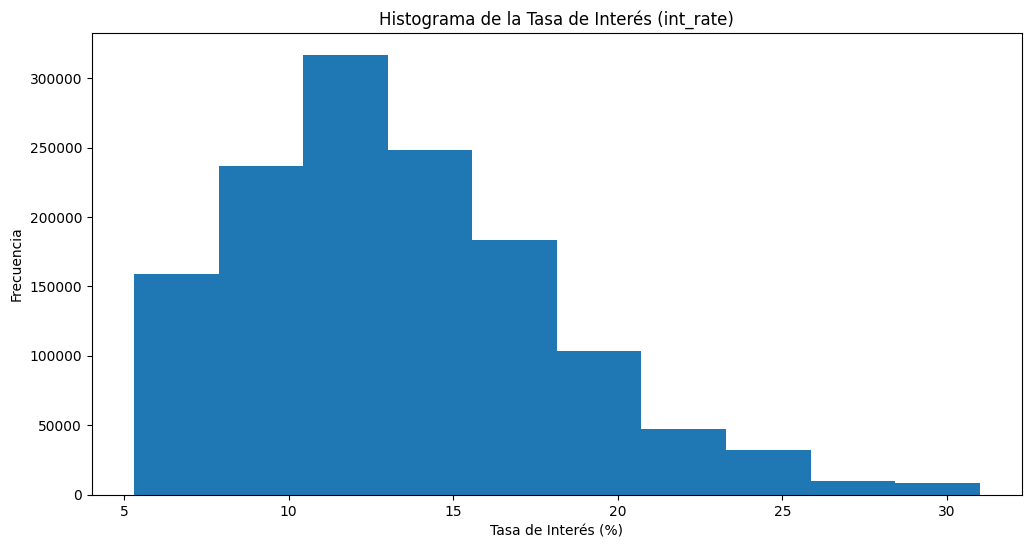

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(df_va['int_rate'])  
plt.title("Histograma de la Tasa de Interés (int_rate)")
plt.xlabel("Tasa de Interés (%)")
plt.ylabel("Frecuencia")
plt.show()

A partir del histograma , la mayoria de prestamos cuentan con tasas de intereses que rondan entre el 10% y 12%. Por otra parte,se llegaron a obtener prestamos aproximadamente del 30% de tasa de interes.

#### **Prestamos por estados de Estados Unidos**

In [23]:
import plotly.graph_objects as go

casos_estado = df_va.groupby("addr_state").size().reset_index()
casos_estado.columns = ["addr_state", "cantidad"]

fig = go.Figure(
    data=go.Choropleth(
        locations=casos_estado["addr_state"],
        locationmode="USA-states",
        z=casos_estado["cantidad"],
        colorscale="Blues",
        colorbar_title="Cantidad de Préstamos",
        hovertemplate="<b>%{location}</b><br>Préstamos: %{z:,}<extra></extra>"
    )
)

fig.update_layout(
    title="Cantidad de Préstamos por Estado",
    geo_scope="usa",
    width=900,
    height=500
)

fig.show()

Con el mapa anterior se logra observar que la mayoria de prestamos se emiten en el estado de California teniendo mas de 300.000, seguidos por el estado de New York y Texas.

#### **Razones de Prestamo**

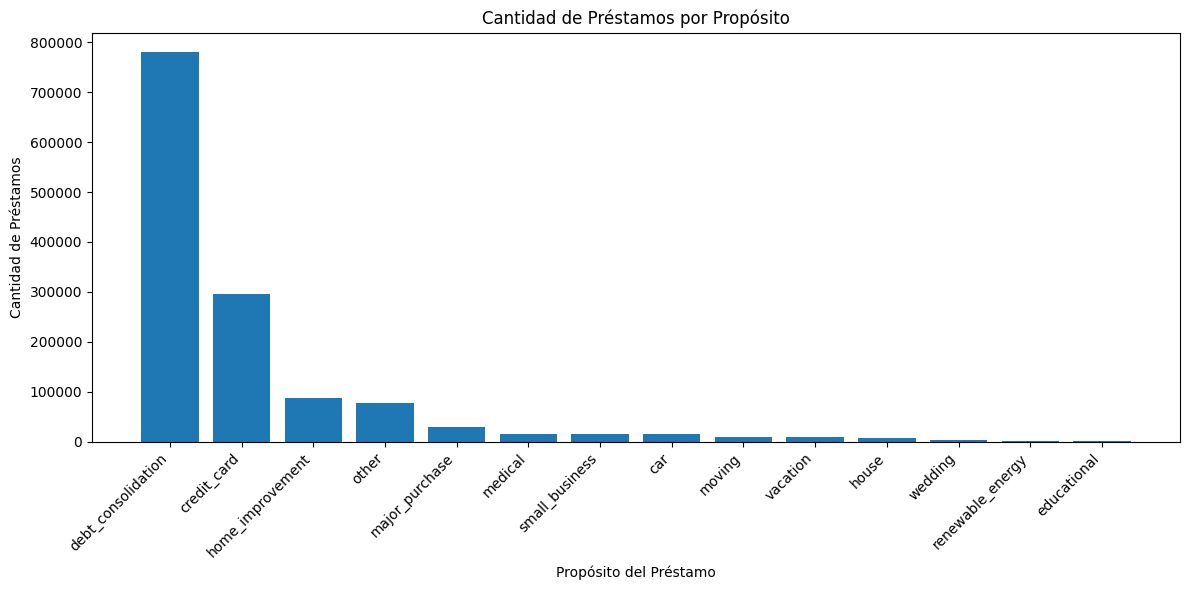

In [24]:
plt.figure(figsize=(12, 6))
plt.bar(df_va["purpose"].value_counts().index, df_va["purpose"].value_counts().values)
plt.title("Cantidad de Préstamos por Propósito")
plt.xlabel("Propósito del Préstamo")
plt.ylabel("Cantidad de Préstamos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

La gran mayoria de usuarios piden prestamos a Lending Club con el fin de cubrir otras deudas. La segunda razon mas comun por la que se adquieren prestamos es para cubrir tarjetas de credito. 

### **calificacion de riesgo a prestamos aceptados**


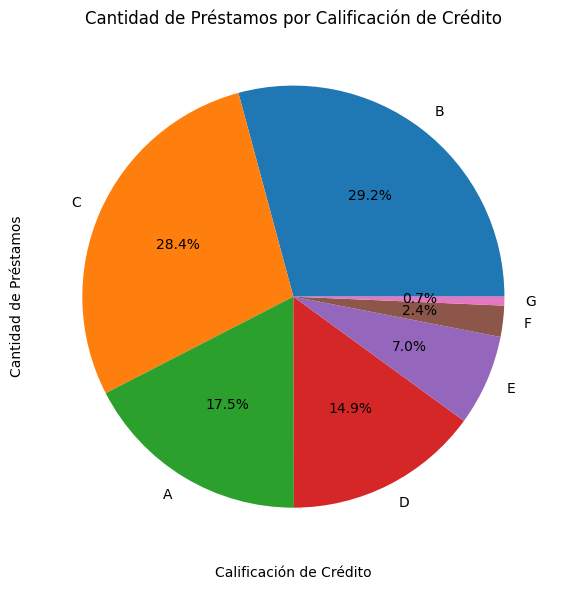

In [25]:
plt.figure(figsize=(12, 6))
plt.pie(df_va["grade"].value_counts().values, labels=df_va["grade"].value_counts().index, autopct='%1.1f%%')
plt.title("Cantidad de Préstamos por Calificación de Crédito")
plt.xlabel("Calificación de Crédito")
plt.ylabel("Cantidad de Préstamos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

La gran mayoria de prestamos aceptados son otorgados a personas con una calificacion de B y C, llevandose casi el 60% de los casos. Mientras que tan solo el 2.4% constituyen a usuarios con una calificacion de G y F.

#### **Mapa Correlaciones**

In [26]:
variables_numericas = ['loan_amnt', 'int_rate', 'fico_range_high', 
                       'annual_inc', 'dti', 'installment', 'open_acc', 'default']

corr = df_va[variables_numericas].corr().round(2)

import plotly.express as px

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Matriz de Correlación con Variable Objetivo (default)",
    width=800,
    height=700
)

fig.show()

La matriz de correlación evidencia una correlación positiva muy fuerte entre el monto del crédito y la cuota mensual, lo cual es evidente ya que a mayor monto solicitado, mayor será el pago mensual del prestatario. Asimismo, se observa una correlación negativa moderada entre el puntaje FICO y la tasa de interés, lo que significa que los solicitantes con mejor historial crediticio reciben tasas más bajas, ya que reflejan menor riesgo.

En cuanto a la variable objetivo default, no se evidencian correlaciones notorias con las variables numéricas analizadas. La mayor relacion es una leve correlación positiva con la tasa de interés, lo que sugiere que los préstamos con tasas más altas tienen una mayor probabilidad de no pagar.

### **Relacion entre el proposito y pago de credito**



In [27]:
import plotly.express as px

tasa = df_va.groupby('purpose')['default'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
tasa.columns = ['purpose', 'Tasa de pago incumplido (%)']

fig = px.bar(
    tasa,
    x='purpose',
    y='Tasa de pago incumplido (%)',
    title='Tasa de pago incumplido por Propósito del Préstamo',
    color='Tasa de pago incumplido (%)',
    color_continuous_scale='Blues',
    text='Tasa de pago incumplido (%)'
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, width=900, height=500)
fig.show()

El gráfico evidencia que los préstamos dirigidos a emprendimientos pequeños presentan la mayor tasa de incumplimiento, alcanzando un 18%, lo que es un alto riesgo  a este tipo de inversiones. Por otro lado, los préstamos para la compra de vehículo  presentan la menor tasa de incumplimiento con un 9.2%, lo que puede ser creditos mas fiables y menos riesgoso para Lending Club.

### **Relacion entre tipo de tenencia de hogar y cumplimiento de credito**

In [28]:
tasa = df_va.groupby('grade')['default'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
tasa.columns = ['grade', 'Tasa de pago incumplido (%)']

fig = px.bar(
    tasa,
    x='grade',
    y='Tasa de pago incumplido (%)',
    title='Tasa de pago incumplido por grado de riesgo',
    color='Tasa de pago incumplido (%)',
    color_continuous_scale='Blues',
    text='Tasa de pago incumplido (%)'
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, width=900, height=500)
fig.show()

Como era de esperarse, los préstamos otorgados a solicitantes con calificación G presentan la mayor tasa de incumplimiento con un 40%, seguidos por aquellos con calificación F con un 34.1%. En cambio, los préstamos con calificación A registran apenas un 3.3% de incumplimiento, lo que confirma que la calificación de riesgo asignada por Lending Club es un predictor clave.

## **Preprocesamiento Scikit Learn**

#### **Importacion de librerias**

In [29]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix)

#### **Seleccionamos target y demas variables**

In [30]:
if "default" not in df_va.columns:
    df_va["default"] = (df_va["loan_status"] == "Charged Off").astype(int)

features = ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
            'annual_inc', 'purpose', 'home_ownership', 'dti', 'addr_state',
            'grade', 'installment', 'open_acc']

target = "default"
features = [col for col in features if col in df_va.columns]
data = df_va[features + [target]].dropna().copy()

X = data[features]
y = data[target]

print(f"Shape X: {X.shape}")
print(f"Distribución target:\n{y.value_counts(normalize=True).mul(100).round(2)}")

Shape X: (1344936, 12)
Distribución target:
default
0    80.04
1    19.96
Name: proportion, dtype: float64


#### **Inicio de preprocesamiento Scikit-learn**

In [31]:
num_cols = [col for col in ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", 
                             "dti", "installment", "open_acc"] if col in X.columns]
cat_cols = [col for col in ["emp_length", "purpose", "home_ownership", 
                             "addr_state", "grade"] if col in X.columns]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print(f"Variables numéricas: {num_cols}")
print(f"Variables categóricas: {cat_cols}")

Variables numéricas: ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'installment', 'open_acc']
Variables categóricas: ['emp_length', 'purpose', 'home_ownership', 'addr_state', 'grade']


#### **Division (80/20) train/ test**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribución train:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"Distribución test:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Train: (1075948, 12) | Test: (268988, 12)
Distribución train:
default
0    80.04
1    19.96
Name: proportion, dtype: float64
Distribución test:
default
0    80.04
1    19.96
Name: proportion, dtype: float64


Se realiza una partición del dataset en conjuntos de entrenamiento (1,075,948 observaciones) y prueba (268,988 observaciones), manteniendo 12 variables predictoras.

Se analiza la distribución de la variable objetivo default, observándose un desbalance de clases, donde la clase 0 representa el 80.04 % de las observaciones y la clase 1 el 19.96%.

La distribución de clases se mantiene consistente entre los conjuntos de entrenamiento y prueba, lo que sugiere que la partición de los datos preserva la proporción original de la variable objetivo.

### Creacion de pipeline

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Columnas numéricas y categóricas
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Pipeline para variables numéricas
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesador completo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

# Aplicar transformación
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

### Preprocesamiento de datos

Se construye un **pipeline de preprocesamiento** para preparar los datos antes del entrenamiento del modelo.

* Las **variables numéricas** imputan valores faltantes con la **mediana** y se escalan con **StandardScaler**.
* Las **variables categóricas** imputan valores faltantes con la **categoría más frecuente** y se transforman con **OneHotEncoder**.

Finalmente, **ColumnTransformer** aplica automáticamente cada transformación al tipo de variable correspondiente.


#### **Aplicacion de GridSearchCV**

In [34]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Modelo base (sin Pipeline)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Grid según requisitos
param_grid = {
    "n_estimators": [10, 50, 100],  # sin "model__"
    "max_depth": [5, 10, 15]
}

# GridSearchCV solo sobre el modelo
grid = GridSearchCV(
    rf,                  # ✅ solo el modelo, no pipe
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
grid.fit(X_train_prep, y_train)  # ✅ datos ya transformados
train_time = time.time() - t0

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor F1 CV: {grid.best_score_:.4f}")
print(f"Tiempo entrenamiento: {train_time:.2f} s")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Mejores hiperparámetros: {'max_depth': 15, 'n_estimators': 100}
Mejor F1 CV: 0.4238
Tiempo entrenamiento: 1219.72 s


El GridSearchCV evalua  todas las combinaciones posibles de hiperparámetros definidas, resultando en este caso 9 combinaciones resultantes de cruzar 3 valores de n_estimators (10, 50, 100) con 3 valores de max_depth (5, 10, 15). Para cada combinación se divide el conjunto de entrenamiento en 3 partes, entrena con 2 y valida con 1, rotando hasta cubrir todas las partes. Esto resulta en 27 modelos entrenados en total, al final de los cuales se va a seleccionar  la combinación con mejor ROC-AUC promedio.

## **Evaluacion Scikit-Learn**

**A continuacion se van a evaluar las metricas para determinar si el modelo es correcto usando los mejores hiperparametros**

In [35]:
mejor_modelo = grid.best_estimator_

start_pred = time.time()
y_pred = mejor_modelo.predict(X_test_prep)        # ← X_test_prep no X_test
t_pred = time.time() - start_pred

y_prob = mejor_modelo.predict_proba(X_test_prep)[:, 1]  # ← X_test_prep no X_test

print(f"Tiempo de predicción: {t_pred:.2f} segundos")
print("\n======== MÉTRICAS RANDOM FOREST ========")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Tiempo de predicción: 1.25 segundos

======== MÉTRICAS RANDOM FOREST ========
Accuracy:  0.6334
Precision: 0.3085
Recall:    0.6734
F1-score:  0.4231
ROC-AUC:   0.7056

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.62      0.73    215290
           1       0.31      0.67      0.42     53698

    accuracy                           0.63    268988
   macro avg       0.60      0.65      0.58    268988
weighted avg       0.77      0.63      0.67    268988



In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\nMatriz de confusión:")
print(f"TN: {tn} | FP: {fp}")
print(f"FN: {fn} | TP: {tp}")


Matriz de confusión:
TN: 134230 | FP: 81060
FN: 17538 | TP: 36160




**Evaluación del modelo Random Forest**

En esta sección se evalúa el rendimiento del modelo **Random Forest** utilizando diferentes métricas de clasificación. El modelo obtiene una **accuracy de aproximadamente 0.63** y un **ROC-AUC de 0.70**, lo que indica una capacidad moderada para distinguir entre préstamos en default y no default.

El reporte de clasificación muestra que el modelo identifica correctamente muchos casos de **No Default**, pero tiene menor precisión al predecir **Default**, lo cual es esperado debido al **desbalance del dataset**.

La **matriz de confusión** permite visualizar el número de predicciones correctas e incorrectas para cada clase, mostrando cómo el modelo clasifica los préstamos entre **Default** y **No Default**. Esto ayuda a entender mejor los errores del modelo y su comportamiento frente a ambas clases.


### **Pyspark**

In [37]:
import os
import sys

JAVA_HOME = os.path.join(sys.prefix, "Library")

os.environ["JAVA_HOME"] = JAVA_HOME
os.environ["PATH"] = os.path.join(JAVA_HOME, "bin") + ";" + os.environ["PATH"]
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

print("JAVA_HOME:", os.environ["JAVA_HOME"])

JAVA_HOME: c:\Users\Juanes Garcia Gomez\anaconda3\envs\miniproyecto1_ml\Library


In [38]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("LendingClub_Default_PySpark")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)
spark



**Inicialización de Spark**

En este bloque se crea una **SparkSession**, que es el punto de entrada para trabajar con Apache Spark desde PySpark.
Se configura el nombre de la aplicación como *LendingClub_Default_PySpark* y se establece el número de particiones para operaciones de shuffle en **200**, lo que ayuda a mejorar el rendimiento en operaciones distribuidas.

Finalmente, se inicia o recupera una sesión de Spark existente utilizando `getOrCreate()`, permitiendo ejecutar procesamiento de datos a gran escala.


In [39]:
df_spark = spark.read.csv(
    r"C:\Users\Juanes Garcia Gomez\Downloads\Machine\Machine\miniproyecto\accepted_2007_to_2018Q4.csv",
    header=True,
    inferSchema=True
)

df_spark.printSchema()
df_spark.show(5)

root
 |-- id: string (nullable = true)
 |-- member_id: string (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- funded_amnt: double (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- url: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- title: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: string 

In [40]:
print("Filas:", df_spark.count())
print("Columnas:", len(df_spark.columns))

status_counts = (
    df_spark.groupBy("loan_status")
    .count()
    .orderBy("count", ascending=False)
)

status_counts.show(10)

Filas: 2260701
Columnas: 151
+--------------------+-------+
|         loan_status|  count|
+--------------------+-------+
|          Fully Paid|1076751|
|             Current| 878317|
|         Charged Off| 268558|
|  Late (31-120 days)|  21467|
|     In Grace Period|   8436|
|   Late (16-30 days)|   4349|
|Does not meet the...|   1988|
|Does not meet the...|    761|
|             Default|     40|
|                NULL|     33|
+--------------------+-------+
only showing top 10 rows




**Exploración inicial del dataset**

En este bloque se realiza una inspección inicial del conjunto de datos.
Primero se muestra el número total de **filas y columnas** del dataset para conocer su tamaño.

Posteriormente se calcula la distribución de la variable **`loan_status`**, agrupando y contando el número de registros en cada categoría. Los resultados se ordenan de mayor a menor para identificar los estados más frecuentes de los préstamos.

Esto permite entender la **distribución de resultados de los préstamos** y detectar posibles desbalances en las clases antes de construir el modelo.


### **Limpieza dataset**

In [41]:
from pyspark.sql.functions import col, when, regexp_replace, trim
from pyspark.sql.types import DoubleType

num_cols = ["loan_amnt","funded_amnt","funded_amnt_inv","int_rate","installment","annual_inc","dti","fico_range_low","fico_range_high"]
cat_cols = ["term","grade","home_ownership","verification_status","purpose","addr_state"]

num_cols = [c for c in num_cols if c in df_spark.columns]
cat_cols = [c for c in cat_cols if c in df_spark.columns]

keep_cols = num_cols + cat_cols
if "loan_status" in df_spark.columns:
    keep_cols += ["loan_status"]

df_spark = df_spark.select(keep_cols)

for c in num_cols:
    df_spark = df_spark.withColumn(c, regexp_replace(col(c).cast("string"), "%", ""))
    df_spark = df_spark.withColumn(c, regexp_replace(col(c), ",", ""))
    df_spark = df_spark.withColumn(
        c,
        when(trim(col(c)) == "", None)
        .when(col(c).rlike("^-?[0-9]+(\\.[0-9]+)?$"), col(c).cast(DoubleType()))
        .otherwise(None)
    )

df_spark = df_spark.cache()
df_spark.count()
print("✅ Limpieza OK")

✅ Limpieza OK




**Creación de la variable objetivo**

En este bloque se crea la variable objetivo **`label`** a partir de la columna `default`.
Primero se limpian los valores de la columna (espacios y formato de texto) y se convierten a mayúsculas para evitar inconsistencias.

Luego se asignan los valores:

* **1** para casos que indican default (`1`, `Y`, `YES`, `TRUE`, `T`)
* **0** para casos que indican no default (`0`, `N`, `NO`, `FALSE`, `F`)

Después se eliminan los registros con valores no válidos y se convierte la variable `label` a tipo entero. Finalmente se muestra la distribución de clases para verificar el número de observaciones en cada categoría.


### **Label y pesos**

In [42]:
df_spark = df_spark.filter(col("loan_status").isin(["Fully Paid", "Charged Off"]))
df_spark = df_spark.withColumn("label", when(col("loan_status") == "Charged Off", 1).otherwise(0))

counts = df_spark.groupBy("label").count().collect()
counts_dict = {row["label"]: row["count"] for row in counts}
n0 = counts_dict.get(0, 1)
n1 = counts_dict.get(1, 1)
total = n0 + n1
w0 = total / (2.0 * n0)
w1 = total / (2.0 * n1)
df_spark = df_spark.withColumn("weight", when(col("label") == 1, w1).otherwise(w0))

print("n0:", n0, "n1:", n1)
print("w0:", w0, "w1:", w1)
df_spark.groupBy("label", "weight").count().orderBy("label").show()

n0: 1076751 n1: 268558
w0: 0.6247075693451876 w1: 2.504689862152682
+-----+------------------+-------+
|label|            weight|  count|
+-----+------------------+-------+
|    0|0.6247075693451876|1076751|
|    1| 2.504689862152682| 268558|
+-----+------------------+-------+





**Balanceo de clases**

En este bloque se calcula un **peso para cada clase** con el objetivo de manejar el desbalance del dataset.
Primero se cuentan las observaciones de cada clase de la variable objetivo (`label`). Luego se calculan pesos inversamente proporcionales al número de ejemplos de cada clase.

De esta forma, la clase minoritaria recibe un **peso mayor**, permitiendo que el modelo preste más atención a esos casos durante el entrenamiento. Finalmente, se añade una nueva columna `weight` al dataset y se verifica la distribución de pesos por clase.


### **Creacion de pipeline**

In [43]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

cols_to_drop = ["label", "loan_status", "weight"]
feature_cols_spark = [c for c in df_spark.columns if c not in cols_to_drop]

num_cols_spark = [c for c in num_cols if c in feature_cols_spark]
cat_cols_spark = [c for c in cat_cols if c in feature_cols_spark]

print("Numéricas:", num_cols_spark)
print("Categóricas:", cat_cols_spark)

imputer = Imputer(
    inputCols=num_cols_spark,
    outputCols=[c + "_imp" for c in num_cols_spark],
    strategy="median"
)

indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in cat_cols_spark]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe") for c in cat_cols_spark]

assembler_inputs = [c + "_imp" for c in num_cols_spark] + [c + "_ohe" for c in cat_cols_spark]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="keep")

rf = RandomForestClassifier(
    numTrees=100,
    maxDepth=10,
    seed=42,
    weightCol="weight",
    featuresCol="features",
    labelCol="label"
)

pipeline_spark = Pipeline(stages=indexers + encoders + [imputer, assembler, rf])
print("Pipeline construido correctamente ✅")

Numéricas: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high']
Categóricas: ['term', 'grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state']
Pipeline construido correctamente ✅




**Construcción del pipeline**

En esta sección se crea el pipeline que combina el **preprocesamiento de los datos** y el **modelo de clasificación**.

Se preparan los datos para el entrenamiento del modelo.
Primero se eliminan las columnas label y loan_status para evitar data leakage, ya que contienen información directamente relacionada con la variable objetivo.

Luego se separan las variables en:

X: variables predictoras utilizadas para entrenar el modelo.

y: variable objetivo (label) que indica si el préstamo terminó en default o no.
Las variables categóricas se procesan imputando los valores faltantes con la categoría más frecuente y aplicando **One-Hot Encoding**. Las variables numéricas se procesan mediante su transformador correspondiente.

Luego se utiliza un **ColumnTransformer** para aplicar las transformaciones según el tipo de variable.

Finalmente, el pipeline integra el preprocesamiento con un **Random Forest Classifier**, configurado para manejar el desbalance de clases y garantizar reproducibilidad del modelo.


### **Se asigna feature**

In [44]:
cols_to_drop = ["label", "loan_status"]
cols_to_drop = [c for c in cols_to_drop if c in df_spark.columns]

feature_cols_spark = [c for c in df_spark.columns if c not in cols_to_drop]

print("Columnas usadas para entrenar:")
print(feature_cols_spark)
print("\n¿Está loan_status en features?", "loan_status" in feature_cols_spark)

Columnas usadas para entrenar:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'term', 'grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'weight']

¿Está loan_status en features? False


### **Entrenamiento del modelo**

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import time

train_spark, test_spark = df_spark.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_spark.count())
print("Test:", test_spark.count())

param_grid = [
    {"numTrees": 100, "maxDepth": 10},
    {"numTrees": 200, "maxDepth": 10},
    {"numTrees": 100, "maxDepth": 15},
]

results = []

for params in param_grid:
    print(f"\nEntrenando: numTrees={params['numTrees']}, maxDepth={params['maxDepth']}")

    rf.setNumTrees(params["numTrees"])
    rf.setMaxDepth(params["maxDepth"])

    start_train = time.time()
    model = pipeline_spark.fit(train_spark)
    train_time = time.time() - start_train

    start_pred = time.time()
    predictions = model.transform(test_spark)
    pred_time = time.time() - start_pred

    auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC").evaluate(predictions)
    acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)
    f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(predictions)

    print("  Matriz de confusión:")
    predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

    print(f"  AUC: {auc:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(f"  Tiempo entrenamiento: {train_time:.2f}s | Predicción: {pred_time:.2f}s")

    results.append({
        "numTrees": params["numTrees"],
        "maxDepth": params["maxDepth"],
        "AUC": round(auc, 4),
        "Accuracy": round(acc, 4),
        "F1": round(f1, 4),
        "Train time (s)": round(train_time, 2),
        "Pred time (s)": round(pred_time, 2)
    })

import pandas as pd
pd.DataFrame(results)

Train: 1076964
Test: 268345

Entrenando: numTrees=100, maxDepth=10
  Matriz de confusión:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0|132880|
|    0|       1.0| 81961|
|    1|       0.0| 17223|
|    1|       1.0| 36281|
+-----+----------+------+

  AUC: 0.7033 | Accuracy: 0.6304 | F1: 0.6673
  Tiempo entrenamiento: 159.18s | Predicción: 0.19s

Entrenando: numTrees=200, maxDepth=10
  Matriz de confusión:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0|131540|
|    0|       1.0| 83301|
|    1|       0.0| 16957|
|    1|       1.0| 36547|
+-----+----------+------+

  AUC: 0.7033 | Accuracy: 0.6264 | F1: 0.6638
  Tiempo entrenamiento: 466.02s | Predicción: 0.18s

Entrenando: numTrees=100, maxDepth=15
  Matriz de confusión:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    0|       0.0|134442|
|    0|       1.0| 80399|
|    1|       0.0| 17443|
|    1|       1.

,numTrees,maxDepth,AUC,Accuracy,F1,Train time (s),Pred time (s)
0,100,10,0.7033,0.6304,0.6673,159.18,0.19
1,200,10,0.7033,0.6264,0.6638,466.02,0.18
2,100,15,0.7068,0.6354,0.6716,429.92,0.16




**Resultados de entrenamiento y predicción**

En esta etapa se muestran los **tiempos de entrenamiento y predicción del modelo Random Forest**. Se tomaron diferentes numeros de arboles y distinta profundidad maxima. A partir de los resultados y las metricas se puede concluir que el mejor modelo es el que toma 100 arboles y profundidad maxima de 10. El entrenamiento del modelo tomó aproximadamente **159.18 segundos**, mientras que el proceso de generar predicciones sobre el conjunto de prueba tardó alrededor de **0.19 segundos**.

Si bien no es el modelo con el mayor AUC ni F1, sus métricas son muy similares a las demás variaciones. Sin embargo, el factor clave es el tiempo de entrenamiento, en donde el modelo con 100 árboles y profundidad 10 fue aproximadamente un 65% más rápido que el de profundidad 15, y un 70% más rápido que el de 200 árboles, lo que lo convierte en la opción más eficiente en términos de costo-beneficio.




In [6]:
# Valores de la matriz de confusión PySpark (numTrees=100, maxDepth=10)
TN = 132880
FP = 81961
FN = 17223
TP = 36281

total = TN + FP + FN + TP

accuracy  = (TP + TN) / total
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1_clase1 = 2 * (precision * recall) / (precision + recall)
f1_weighted = 0.6673  

print(f"Accuracy:       {accuracy:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 clase 1:     {f1_clase1:.4f}" )
print(f"F1 weighted:    {f1_weighted:.4f} ")


Accuracy:       0.6304
Precision:      0.3068
Recall:         0.6781
F1 clase 1:     0.4225
F1 weighted:    0.6673 


Cabe recalcar que el F1-score reportado en la anterior tabla es el F1 weighted — es decir, el promedio ponderado del F1 de ambas clases (Fully Paid y Charged Off). Este es diferente del F1 de clase 1 el cual es Charged Off únicamente, que resulta en 0.4225, y es el valor que se puede comparar respecto al F1 reportado en el modelo de Scikit-learn.



**Evaluación del modelo**

Los resultados muestran que el modelo obtiene una **accuracy de aproximadamente 0.63**, lo que indica que cerca del 63 % de las predicciones totales son correctas. El **ROC-AUC de 0.70** sugiere que el modelo tiene una capacidad moderada para distinguir entre préstamos en *default* y *no default*.


La **matriz de confusión** muestra que el modelo clasifica correctamente **132 880 casos de no default** y **36 281 casos de default**, mientras que comete errores en **82 426 falsos positivos** y **17 223 falsos negativos**. Estos resultados reflejan el desafío del **desbalance de clases** presente en el dataset.


In [46]:
# Usar el mejor modelo (100 árboles, profundidad 10)
rf.setNumTrees(100)
rf.setMaxDepth(10)
best_model = pipeline_spark.fit(train_spark)
predictions = best_model.transform(test_spark)
print("✅ Usando modelo: numTrees=100, maxDepth=10")

✅ Usando modelo: numTrees=100, maxDepth=10


In [47]:
from pyspark.sql.functions import udf, when
from pyspark.sql.types import DoubleType

# Extraer probabilidad de clase 1
extract_prob = udf(lambda v: float(v[1]), DoubleType())
predictions = predictions.withColumn("p1", extract_prob(col("probability")))

thresholds = [0.50, 0.30, 0.20, 0.15, 0.10, 0.05]

def eval_threshold(predictions, TH):
    tmp = predictions.withColumn(
        "pred_thr",
        when(col("p1") >= TH, 1).otherwise(0)
    )

    tp = tmp.filter((col("label") == 1) & (col("pred_thr") == 1)).count()
    tn = tmp.filter((col("label") == 0) & (col("pred_thr") == 0)).count()
    fp = tmp.filter((col("label") == 0) & (col("pred_thr") == 1)).count()
    fn = tmp.filter((col("label") == 1) & (col("pred_thr") == 0)).count()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    acc       = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0

    return (TH, acc, precision, recall, f1, tp, fp, fn, tn)

results = [eval_threshold(predictions, th) for th in thresholds]

print("TH   | Acc    | Prec   | Rec    | F1     | TP     FP     FN     TN")
for r in results:
    print(f"{r[0]:.2f} | {r[1]:.4f} | {r[2]:.4f} | {r[3]:.4f} | {r[4]:.4f} | {r[5]} {r[6]} {r[7]} {r[8]}")

# ---- THRESHOLD FINAL ----
TH = 0.15
predictions = predictions.withColumn(
    "pred_thr",
    when(col("p1") >= TH, 1).otherwise(0)
)

print("\nPredicciones con threshold final:")
predictions.select("label", "p1", "pred_thr").show(10)

TH   | Acc    | Prec   | Rec    | F1     | TP     FP     FN     TN
0.50 | 0.6304 | 0.3068 | 0.6781 | 0.4225 | 36281 81961 17223 132880
0.30 | 0.2886 | 0.2161 | 0.9777 | 0.3540 | 52309 189716 1195 25125
0.20 | 0.1994 | 0.1994 | 1.0000 | 0.3325 | 53504 214841 0 0
0.15 | 0.1994 | 0.1994 | 1.0000 | 0.3325 | 53504 214841 0 0
0.10 | 0.1994 | 0.1994 | 1.0000 | 0.3325 | 53504 214841 0 0
0.05 | 0.1994 | 0.1994 | 1.0000 | 0.3325 | 53504 214841 0 0

Predicciones con threshold final:
+-----+-------------------+--------+
|label|                 p1|pred_thr|
+-----+-------------------+--------+
|    1| 0.5092912126832322|       1|
|    0| 0.2424777691960694|       1|
|    0| 0.2935141509289045|       1|
|    0| 0.2398973518002617|       1|
|    0| 0.2443370137050455|       1|
|    0| 0.2865275185625795|       1|
|    0|0.29197221566413495|       1|
|    0|0.32723927534355746|       1|
|    0|0.35908032294253256|       1|
|    0| 0.3643789073412838|       1|
+-----+-------------------+--------+
only 



**Selección del threshold**

Se puede observar que a medida que se reduce el threshold, el recall aumenta significativamente, debido a que el modelo clasifica como default cualquier préstamo, en donde la probabilidad supere el umbral definido. Al reducir el umbral, el modelo toma una mayor proporción de defaults reales, reduciendo los falsos negativos. En riesgo crediticio el threshold 0.30 es el mas optimo ya que maximiza la detección de defaults con un recall de 0.97, y se  mantiene aún cierta capacidad de discriminar préstamos buenos, a diferencia de thresholds más bajos que colapsan en predecir default para todos.

ROC-AUC: 0.703306057384955


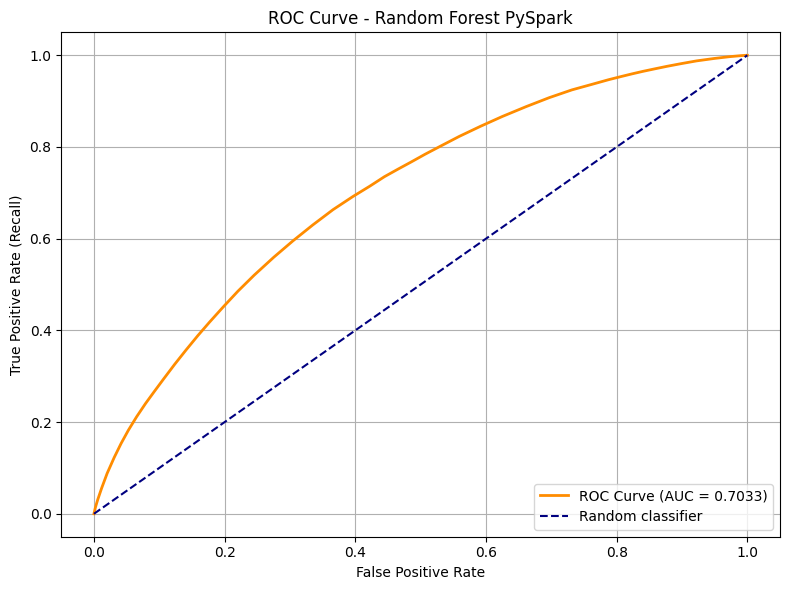

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import numpy as np

extract_prob = udf(lambda v: float(v[1]), DoubleType())
predictions = predictions.withColumn("p1", extract_prob(col("probability")))

# AUC con PySpark
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = auc_evaluator.evaluate(predictions)
print("ROC-AUC:", auc)

# Recolectar probabilidades y labels para graficar
pdf = predictions.select("label", "p1").toPandas()

# Calcular curva ROC manualmente
thresholds = np.linspace(0, 1, 100)
tprs, fprs = [], []

for th in thresholds:
    tp = ((pdf["label"] == 1) & (pdf["p1"] >= th)).sum()
    fn = ((pdf["label"] == 1) & (pdf["p1"] < th)).sum()
    fp = ((pdf["label"] == 0) & (pdf["p1"] >= th)).sum()
    tn = ((pdf["label"] == 0) & (pdf["p1"] < th)).sum()

    tprs.append(tp / (tp + fn) if (tp + fn) else 0)
    fprs.append(fp / (fp + tn) if (fp + tn) else 0)

# Grafica
plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Random Forest PySpark")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

**Cálculo del ROC-AUC**

En esta celda se calcula la métrica **ROC-AUC (Area Under the ROC Curve)** para evaluar la capacidad del modelo de distinguir entre préstamos en **default** y **no default**.
El resultado obtenido es **ROC-AUC ≈ 0.70**, lo que indica que el modelo tiene una **capacidad moderada de discriminación**, es decir, logra separar razonablemente ambas clases mejor que una clasificación aleatoria (0.5), de igual manera puede mejorar su capacidad de clasificar.


## Interpretabilidad de LIME



La **interpretabilidad con LIME (Local Interpretable Model-agnostic Explanations)** permite entender cómo un modelo de machine learning toma decisiones para una predicción específica. LIME funciona generando pequeñas variaciones de una observación y analizando cómo cambian las predicciones del modelo. Con esta información, construye un **modelo simple y local** que aproxima el comportamiento del modelo complejo alrededor de esa instancia.

De esta manera, LIME identifica **qué variables influyen más en la predicción**, mostrando cuáles empujan la decisión hacia una clase u otra. Esto es especialmente útil para interpretar modelos complejos como **Random Forest**, ya que permite explicar sus decisiones de forma transparente y comprensible a nivel individual.


In [ ]:
import numpy as np
import pandas as pd

pred_labels = mejor_modelo.predict(X_test_prep)
probs = mejor_modelo.predict_proba(X_test_prep)

lime_results = X_test.copy()
lime_results["label"] = y_test.values
lime_results["prediction"] = pred_labels
lime_results["probability_1"] = probs[:, 1]

# Casos mal clasificados
wrong_preds = lime_results[lime_results["label"] != lime_results["prediction"]].copy()

print("Número de errores:", len(wrong_preds))
print(wrong_preds[["label", "prediction", "probability_1"]].head(10))

Número de errores: 98598
         label  prediction  probability_1
667494       0           1       0.502637
1976253      0           1       0.517980
1206220      0           1       0.618020
1945945      1           0       0.267308
1305249      0           1       0.632711
1778315      0           1       0.571033
1900116      1           0       0.366159
1795232      0           1       0.771245
1865761      0           1       0.616707
384275       0           1       0.504263


**Análisis de predicciones incorrectas**

En esta celda se identifican los casos en los que el modelo **clasificó incorrectamente** las observaciones del conjunto de prueba. Para ello, se comparan las etiquetas reales (`label`) con las predicciones del modelo (`prediction`) y se seleccionan aquellas filas donde no coinciden.

El resultado muestra que el modelo cometió **98,598 errores de clasificación**. Además, se visualizan algunos ejemplos junto con la **probabilidad estimada de default (`probability_1`)**, lo que permite analizar situaciones donde el modelo estaba relativamente seguro pero aun así se equivocó.

Este paso es útil para **analizar errores del modelo** y posteriormente aplicar técnicas de interpretabilidad, como **LIME**, para entender qué variables influyeron en esas predicciones incorrectas.


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML
import numpy as np
import pandas as pd



# 2) Nombres de features transformadas
feature_names = preprocessor.get_feature_names_out()

# 3) Función de predicción para LIME
def predict_fn(x):
    return mejor_modelo.predict_proba(x)

explainer = LimeTabularExplainer(
    training_data=X_train_prep,
    feature_names=feature_names,
    class_names=["Fully Paid", "Charged Off"],
    mode="classification"
)

pred_labels = mejor_modelo.predict(X_test_prep)
probs = mejor_modelo.predict_proba(X_test_prep)

wrong_idx = np.where(y_test.values != pred_labels)[0]
print("Número de errores:", len(wrong_idx))

i = wrong_idx[0]

exp = explainer.explain_instance(
    data_row=X_test_prep[i],
    predict_fn=predict_fn,
    num_features=10
)

print("Label real:", y_test.iloc[i])
print("Predicción:", pred_labels[i])
print("Probabilidad clase 1:", probs[i, 1])

print("\nVariables más influyentes:")
for item in exp.as_list():
    print(item)

HTML(exp.as_html())

Número de errores: 98598
Label real: 0
Predicción: 1
Probabilidad clase 1: 0.5026371340234

Variables más influyentes:
('num__int_rate', 0.06546650293828943)
('cat__home_ownership_MORTGAGE', -0.03561857062108267)
('num__loan_amnt', 0.018322933009839157)
('num__dti', 0.016577348952670528)
('num__annual_inc', -0.014536404799420278)
('num__fico_range_high', -0.012873380120929473)
('num__installment', 0.012672559634457467)
('cat__addr_state_CA', -0.01175247662912165)
('cat__emp_length_10+ years', 0.005109531427698362)
('cat__purpose_debt_consolidation', -0.004381035904510006)


**Interpretación con LIME**

En esta sección se utiliza **LIME (Local Interpretable Model-agnostic Explanations)** para analizar una predicción específica que el modelo clasificó incorrectamente.

El caso analizado corresponde a un préstamo cuya **etiqueta real es 0 (Fully Paid)**, pero el modelo lo **predijo como 1 (Default)** con una **probabilidad de aproximadamente 0.56**. Esto indica que el modelo tenía una ligera inclinación hacia la clase de default, lo que provocó el error de clasificación.

Enre las variables se puede observar que "num_int_rate" , "num_loan_amnt","num_dti" , "num_installment", entre otros, influyen para que el prestamo sea "charged off". Mientras que "cat_home_ownership_mortage", "num_annual_inc",  "num_fico_range_high", entre otros, aumentan la probabilidad de que sea "fully_paid".




**Selección de una observación mal clasificada**

In [51]:
# Elegir una observación mal clasificada
idx = wrong_preds.index[2]

# Posición en X_test (no índice del df original)
pos = list(X_test.index).index(idx)

x_instance = X_test_prep[pos]  # ← usar datos transformados
true_label = y_test.loc[idx]
pred_label = pred_labels[pos]
pred_prob = probs[pos, 1]

print("Índice:", idx)
print("Label real:", true_label)
print("Predicción:", pred_label)
print("Probabilidad clase 1:", pred_prob)

Índice: 1206220
Label real: 0
Predicción: 1
Probabilidad clase 1: 0.6180201402739555




En esta celda se selecciona una **observación del conjunto de prueba que el modelo clasificó incorrectamente**. Para ello, se toma el primer índice del conjunto `wrong_preds`, que contiene todos los casos donde la **predicción del modelo no coincide con la etiqueta real**.

Luego se extraen:

* **`x_instance`**: los valores de las variables de esa observación.
* **`true_label`**: la etiqueta real.
* **`pred_label`**: la predicción realizada por el modelo.
* **`pred_prob`**: la probabilidad estimada de la clase 1 (default).

En este caso concreto, el registro con **índice 1206220** tiene **etiqueta real 0 (no default)**, pero el modelo lo **clasificó como 1 (default)** con una **probabilidad aproximada de 0.61**, lo que representa un **falso positivo**. Este tipo de observaciones se van a utilizar posteriormente para aplicar **LIME** y analizar qué variables influyeron en la decisión del modelo.


**Explicación local con LIME**

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML
import numpy as np

feature_names = preprocessor.get_feature_names_out()

if hasattr(X_train_prep, "toarray"):
    X_train_prep = X_train_prep.toarray()
if hasattr(X_test_prep, "toarray"):
    X_test_prep = X_test_prep.toarray()

explainer = LimeTabularExplainer(
    training_data=X_train_prep,
    feature_names=feature_names,
    class_names=["Fully Paid", "Charged Off"],
    mode="classification"
)

# Función de predicción para LIME
def predict_fn(x):
    return mejor_modelo.predict_proba(x)

# Elegir una observación mal clasificada
i = wrong_idx[2]
x_instance = X_test_prep[i]


exp = explainer.explain_instance(
    data_row=x_instance,
    predict_fn=predict_fn,
    num_features=10
)

print("Label real:", y_test.iloc[i])
print("Predicción:", pred_labels[i])
print("Probabilidad clase 1:", probs[i, 1])

print("\nVariables más influyentes:")
for item in exp.as_list():
    print(item)

HTML(exp.as_html())

Label real: 0
Predicción: 1
Probabilidad clase 1: 0.6180201402739555

Variables más influyentes:
('num__int_rate > 0.58', 0.11277152365037416)
('cat__grade_A <= 0.00', 0.10702670022538767)
('cat__grade_B <= 0.00', 0.06404439969973456)
('cat__addr_state_DC <= 0.00', 0.05691120026985037)
('cat__addr_state_OR <= 0.00', 0.04996082229875021)
('cat__addr_state_WA > 0.00', -0.032588093848795095)
('cat__addr_state_CO <= 0.00', 0.027842366451100317)
('cat__purpose_renewable_energy <= 0.00', -0.01916856787169369)
('cat__home_ownership_ANY <= 0.00', 0.01005506376072879)
('cat__purpose_educational <= 0.00', -0.007963008350439525)




En esta celda se aplica **LIME** para interpretar la predicción de una observación específica del conjunto de prueba. Primero se selecciona una instancia (`i = 3`) y se utiliza el método `explain_instance` para generar una explicación local de la predicción del modelo, considerando las **10 variables más influyentes**.

El gráfico resultante muestra las **probabilidades de predicción** para cada clase: en este caso, el modelo estima aproximadamente **0.62 de probabilidad de “charged off”** y **0.38% de fully paid”**, por lo que clasifica el préstamo como **charged off**.

Además, LIME presenta las **variables que más contribuyen a esta decisión**, indicando cuáles empujan la predicción hacia cada clase. Entre las variables relevantes aparece sobretodo "num_int_rate" donde La tasa de interés de este préstamo se encuentra 0.58 desviaciones estándar por encima de la media, lo que el modelo interpreta como una señal de riesgo alta de no pago del prestamo, aunque el cliente si haya pagado el prestamo en realidad.



**Importancia de variables con LIME (análisis global aproximado)**

In [53]:
from collections import Counter

n_instances = 100
top_k = 8

counter = Counter()

for i in range(min(n_instances, X_test_prep.shape[0])):

    exp = explainer.explain_instance(
        data_row=X_test_prep[i],
        predict_fn=predict_fn,
        num_features=top_k
    )

    for feat, w in exp.as_list():
        base_feat = feat.split(" ")[0]
        counter[base_feat] += 1

print("Variables más frecuentes en Top-k (LIME):\n")

for f, c in counter.most_common(20):
    print(f"{f}: {c}")

Variables más frecuentes en Top-k (LIME):

cat__grade_A: 100
cat__grade_B: 73
cat__addr_state_OR: 63
num__int_rate: 55
cat__addr_state_WA: 48
cat__purpose_renewable_energy: 38
cat__purpose_educational: 30
cat__home_ownership_ANY: 28
0.00: 27
cat__addr_state_ME: 25
cat__addr_state_CO: 25
cat__addr_state_ND: 24
cat__purpose_wedding: 23
cat__addr_state_ID: 22
cat__addr_state_VT: 19
cat__addr_state_NH: 19
cat__home_ownership_OTHER: 18
cat__addr_state_DC: 17
num__loan_amnt: 16
cat__addr_state_WY: 15




En esta sección se aplica **LIME** a múltiples observaciones del conjunto de prueba para identificar qué variables aparecen con mayor frecuencia entre las más influyentes en las predicciones del modelo. Se analizan **100 instancias** y, para cada una, se extraen las **8 características más importantes**.

Los resultados muestran que variables como **""cat_grade_A""(es influyente en todas las observaciones), "cat_grade_B" **, **`term` (plazo)** y **"num_int_rate` (tasa de interés)"" aparecen con mayor frecuencia entre las explicaciones generadas por LIME. Esto sugiere que estas características tienen una alta influencia en la decisión del modelo sobre el riesgo de default.

Este análisis proporciona una **visión global aproximada de la interpretabilidad del modelo**, complementando las explicaciones locales generadas por LIME para cada observación individual.


## Comparacion y Evaluacion de modelos

A continuacion se van a comparar cada uno de los modelos usados y sus respectivas metricas para verificar cual es el nmas efectivo en este dataset.

In [2]:
import pandas as pd

comparacion = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Scikit-learn": [0.6334, 0.3085, 0.6734, 0.4231],
    "PySpark":      [0.6304, 0.3068, 0.6781, 0.4225]
})

comparacion = comparacion.set_index("Métrica")
print(comparacion)

           Scikit-learn  PySpark
Métrica                         
Accuracy         0.6334   0.6304
Precision        0.3085   0.3068
Recall           0.6734   0.6781
F1-score         0.4231   0.4225


Al comparar las métricas de ambos modelos, se observa que Scikit-learn tiene valores levemente superiores en Accuracy (0.6334 vs 0.6304), y precision (0.3085 vs 0.3068) y F1-score (0.4231 vs 0.4225). Sin embargo, PySpark supera a Scikit-learn en Recall (0.6781 vs 0.6734), lo que indica que detecta una mayor proporción de defaults reales. De igual manera, las diferencias entre ambos modelos son mínimas — inferiores al 1% en todas las métricas.

### **Tiempos**



In [9]:
import pandas as pd

tiempos = pd.DataFrame({
    "Fase": ["Entrenamiento", "Predicción"],
    "Scikit-learn (s)": [1266.00, 0.89],
    "PySpark (s)": [159.18, 0.19]})

tiempos = tiempos.set_index("Fase")
print(tiempos.to_string())

               Scikit-learn (s)  PySpark (s)
Fase                                        
Entrenamiento           1266.00       159.18
Predicción                 0.89         0.19


De acuerdo al tiempo de ejecucion, pyspark demostró una gran diferencia frente a Scikit-learn en entrenamiento y prediccion. En la primera fase , PySpark redujo el tiempo de 1266 segundos a tan solo 159 segundos, siendo aproximadamente 7.9 veces más rápido. En la predicción, la diferencia se mantuvo con PySpark completando el proceso en 0.19 segundos frente a los 0.89 segundos de Scikit-learn, es decir, 4.7 veces más rápido. Lo que demuestra una mayor eficiencia en tiempo cuando se toma una base de datos con gran tamaño, en donde las demas metricas no difieren mucho.

### **ROC-AUC**

In [12]:
import pandas as pd

roc_auc = pd.DataFrame({
    "Métrica": ["ROC-AUC"],
    "Scikit-learn": [0.7056],
    "PySpark": [0.7033]
})

roc_auc = roc_auc.set_index("Métrica")
print(roc_auc.to_string())

         Scikit-learn  PySpark
Métrica                       
ROC-AUC        0.7056   0.7033


Respecto a esta metrica ambos modelos obtuvieron valores de ROC-AUC muy similares, con Scikit-learn alcanzando 0.7056 y PySpark 0.7033. La diferencia entre ambos es de apenas 0.0023, lo que representa menos del 0.3% de variación. Esto muestra que ambos modelos tienen una capacidad prácticamente equivalente para clasificar entre préstamos que serán pagados y los que van a ser default.

### **Umbral de decision**

Teniendo en cuenta el umbral de decisión, en el modelo PySpark se evaluaron distintos valores de threshold con el objetivo de optimizar la detección de defaults. Con el threshold en 0.50, el modelo obtuvo un Recall de 0.6781, dejando escapar una proporción considerable de defaults reales. Al reducir el threshold a 0.30, el Recall aumentó significativamente a 0.9777, detectando casi la totalidad de los préstamos en riesgo,  a cambio de una reducción en la precisión del 0.2161. A partir de un threshold de 0.20, el modelo colapsa prediciendo todo como default, perdiendo toda capacidad discriminativa. Por lo tanto, el threshold óptimo es 0.30, ya que maximiza la detección de defaults manteniendo aún cierta capacidad de distinguir préstamos buenos, donde el costo de no detectar un default supera ampliamente el de una falsa alarma.

### **Conclusion de las comparaciones**

- El modelo Random Forest optimizado demostró una capacidad discriminativa moderada, con un ROC-AUC de 0.7033 en PySpark y 0.7056 en Scikit-learn, de igual manera tienen ambos un margen de mejora. 

- Se observó un comportamiento robusto frente al desbalance de clases gracias al uso de pesos balanceados (class_weight="balanced" en Scikit-learn y weightCol en PySpark), lo que permitió al modelo mantener un Recall fuerte. De igual manera, poder evaluar distintos puntos del umbral de decisión, se pudo observar que ajustando el threshold a 0.30, el modelo alcanza un Recall de 0.9777, detectando casi todos los defaults reales, lo que ayuda a determinar scoring crediticio donde minimizar los falsos negativos es prioritario. 

- En conclusión, aunque las métricas globales tienen un amplio margen de mejora, el modelo desarrollado sirve como apoyo a la toma de decisiones financieras, con capacidad de mejorar mediante PySpark ante volúmenes de datos mayores.

## **Conclusiones Generales**

### **Preparación y análisis de los datos**
Inicialmente se realizó la carga y exploración del dataset de LendingClub, el cual contiene registros de préstamos entre 2007 y 2018 con más de 1.3 millones de observaciones tras el filtrado de las clases relevantes. Se analizó la estructura de las variables, los tipos de datos y la presencia de valores faltantes. Los datos fueron divididos en conjuntos de entrenamiento (80%) y prueba (20%).
Durante esta etapa se observó que la variable objetivo **default** presenta un desbalance de clases significativo, con 1,076,751 casos de Fully Paid **clase 0** y 268,558 casos de Charged Off **clase 1**. Este desbalance es común en problemas de riesgo crediticio y fue un desafío importante para implementar estos modelo de clasificación.

### **Preprocesamiento de datos**
El preprocesamiento se implementó diferenciando entre variables numéricas y categóricas:
Variables numéricas: loan_amnt, int_rate, fico_range_high, annual_inc, dti, installment, open_acc

Imputación de valores faltantes con la mediana
Estandarización con StandardScaler

Variables categóricas: emp_length, purpose, home_ownership, addr_state, grade

- Se hizo la Imputación con la categoría más frecuente

- La transformación se hizo con OneHotEncoder

En PySpark el preprocesamiento se realizó mediante StringIndexer, OneHotEncoder, Imputer y VectorAssembler integrados en un Pipeline.

### **Construcción del modelo**
El modelo utilizado fue RandomForestClassifier, implementado tanto en Scikit-learn como en PySpark, y luego se hizo la  comparacion mediante las metricas. Para abordar el desbalance de clases se utilizó:

class_weight="balanced" en Scikit-learn
weightCol="weight" con pesos calculados manualmente en PySpark (w0=0.62, w1=2.50)


### **Selección de hiperparámetros**
Se evaluaron las siguientes combinaciones:
n_estimators / numTreesmax_depth10, 50, 1005, 10, 15
En Scikit-learn se utilizó GridSearchCV con 3 folds, optimizando el F1-score. Los mejores hiperparámetros fueron max_depth=15, n_estimators=100.
En PySpark se probaron manualmente 3 combinaciones, seleccionando numTrees=100, maxDepth=10 como el modelo óptimo en términos de costo-beneficio.

### **Evaluación del modelo**
Ambos modelos obtuvieron métricas prácticamente equivalentes, con diferencias inferiores al 1%. Sin embargo, PySpark fue significativamente mas eficiente con respecto al tiempo de entrenamiento y predicción.

### **Análisis del Threshold**
Se evaluaron distintos umbrales de decisiones desde 0.5, 0.3, 0.2 y mediante las metrocas se pudo observar que el threshold óptimo es 0.30, maximizando la detección de defaults con un Recall de 0.9777.

## **Conclusión final**

Los resultados obtenidos muestran que el modelo Random Forest implementado en PySpark con threshold=0.30 representa la solución más adecuada para este problema. Aunque las métricas globales son moderadas (AUC~0.70), el modelo detecta el 97.77% de los defaults reales con el threshold ajustado, siendo eficiente computacionalmente y escalable para volúmenes de datos mayores. Esto lo convierte en una herramienta viable para apoyar procesos de evaluación crediticia y gestión de riesgo financiero.
-
